## Definig functions

1. `def` introduces a function definition.
2. It must be followed by the function name and the parenthesized list of formal **parameters**.

In [ ]:
# prints Fibonacci series up to n
def fib(n):
  """
  Print a Fibonacci series up to n.
  """
  a,b = 0,1

  while a < n:
    print(a,end=",")
    a,b= b, a+b
  print()



In [ ]:
# Now call the function we just defined:
fib(10)

### Explanation
1. The first statement of the function body can *optionally* be a **string literal**; also known as **document(doc) string**
  1.  it’s good practice to include docstrings in code that you write, so make a habit of it.
2. all variable assignments in a function store the value in the local symbol table;

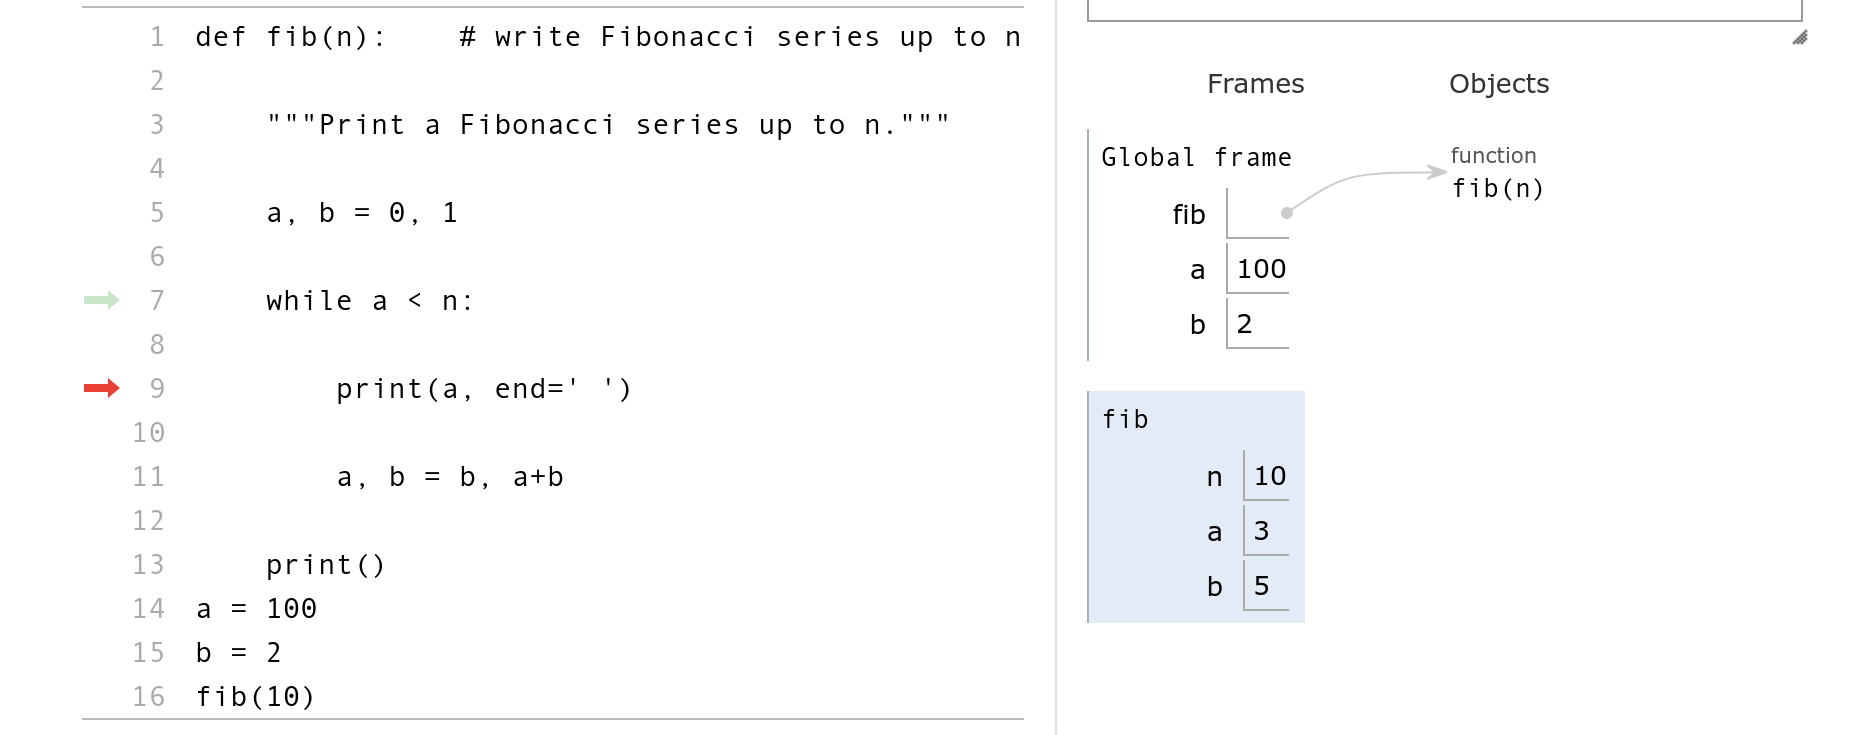
blue color is the local table in the image
3. variable lookup hierarchy
  1. local table
  2. global table
  3. builtin table
4. Thus, global variables and variables of enclosing functions cannot be directly assigned a value within a function (unless, for global variables, named in a global statement, or, for variables of enclosing functions, named in a nonlocal statement)
5. when you invoke (call) the function along with argument, function gets the specal space called local table to store it's information.
6. The `return` statement returns with a value from a function. `return` without an expression argument returns `None`.
7. if your function finishes executing all its code without encountering an explicit return statement, it will implicitly `return` the special value `None`.

In [ ]:
f = fib
f(100) # this is possible, like any other object we can assign the function to a variable

## Call by value vs call by reference

Python's argument passing mechanism is often described as **pass by object reference** or **pass by assignment.** It's not strictly "call by value" or "call by reference" in the way those terms are used in languages like C++ or Java.

### Behaves like "Call by Value" for Immutable Objects
When you pass immutable objects (like numbers, strings, tuples) to a function, any reassignment of the parameter inside the function **does not affect the original variable outside the function.**
<br>
This is because immutables cannot be changed in place; reassigning them creates a new object, and the function's parameter now points to this new object, leaving the original object (and the outside variable's reference to it) untouched.

In [ ]:
def modify_number(num):
  num = num + 10
  return num

original_number = 5
# function call
modify_number(original_number)

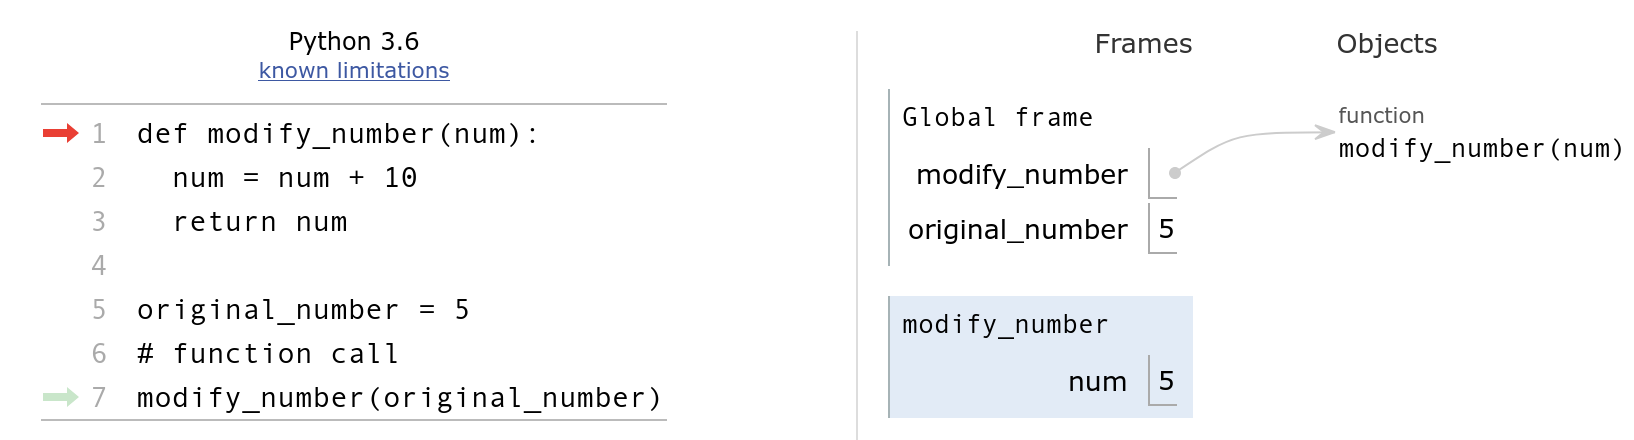

### Behaves like "Call by Reference" for Mutable Objects (for in-place modifications)

When you pass mutable objects (like lists, dictionaries, sets) to a function, if you modify the contents of the object in-place within the function, **those changes will be reflected in the original variable outside the function.** This is because both the original variable and the function's parameter are referring to the same object in memory.

In [ ]:
def modify_list_in_place(my_list):
    my_list = [4,6,7]
    return my_list
original_list = [1, 2, 3]

modify_list_in_place(original_list)

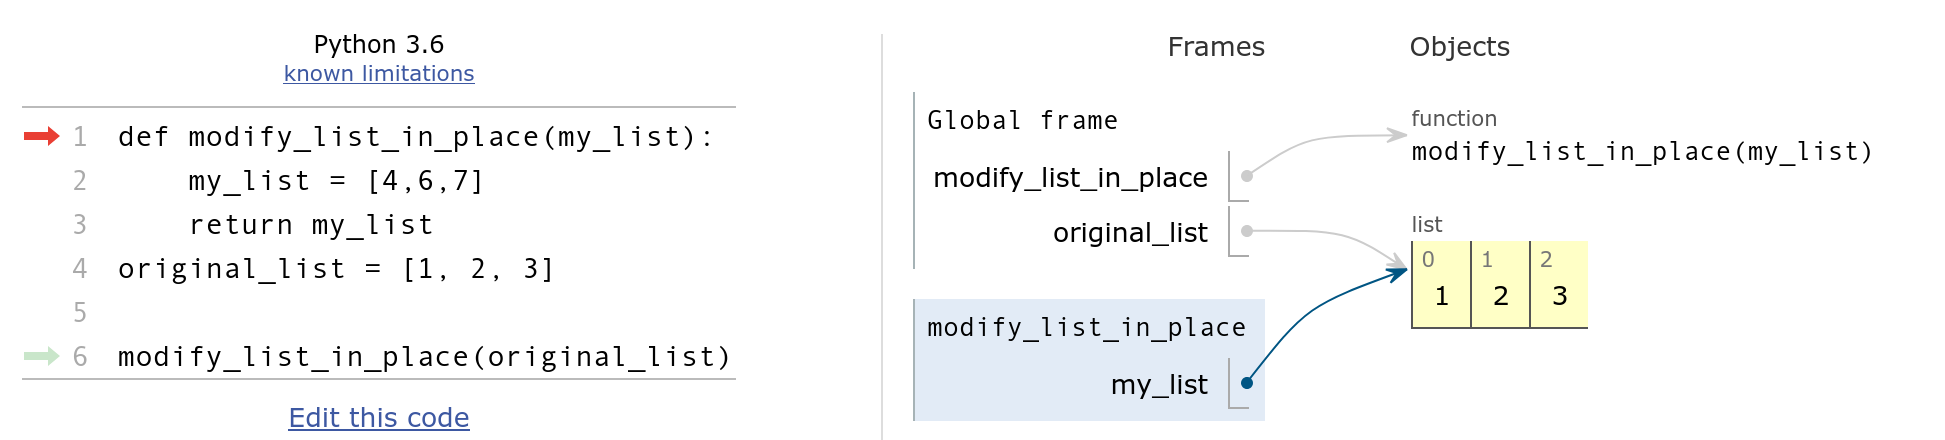

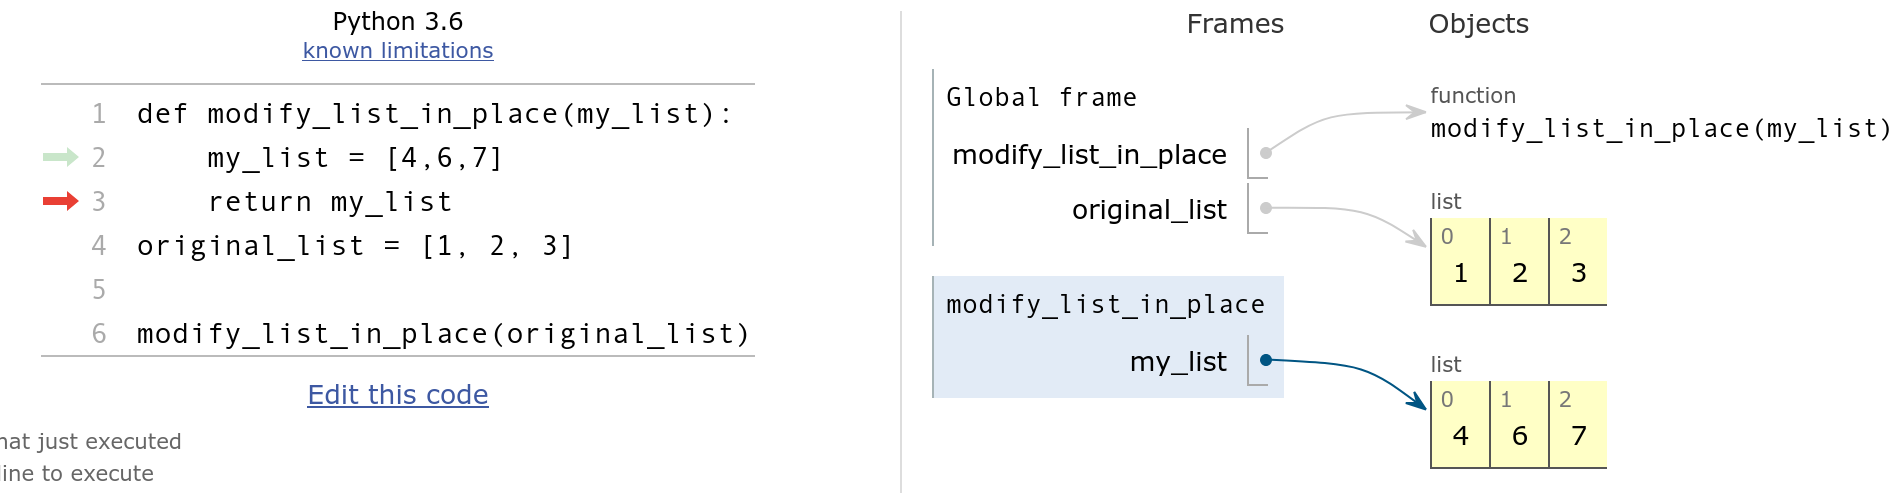

## Function arguments

### DEFAULT ARGUMENTS

are about what happens if argument is NOT provided

In [ ]:
def greet(name, greeting="Hello", punctuation="!"):
    """Greet someone with customizable greeting and punctuation."""
    return f"{greeting}, {name}{punctuation}"

# Try calling it different ways:
print(greet("Alice"))                    # Uses defaults
print(greet("Bob", "Hi"))                # Override greeting
print(greet("Charlie", "Hey", "?"))      # Override both

In [ ]:
def greet(name, greeting="Hello", punctuation="!",capitalize =True):
    """Greet someone with customizable greeting and punctuation."""
    if capitalize:
      return f"{greeting.upper()}, {name.upper()}{punctuation}"
    return f"{greeting}, {name}{punctuation}"

# Try calling it different ways:
print(greet("Alice"))                    # Uses defaults
print(greet("Bob", "Hi"))                # Override greeting
print(greet("Charlie", "Hey", "?"))      # Override both

HELLO, ALICE!
HI, BOB!
HEY, CHARLIE?


In [ ]:
# The mutable default gotcha - this is important!
def add_item_wrong(item, items_list=[]):
    """DON'T DO THIS - mutable default"""
    items_list.append(item)
    return items_list

# Watch what happens:
print("\nMutable default problem:")
print(add_item_wrong("apple"))   # ['apple']
print(add_item_wrong("banana"))  # ['apple', 'banana'] - Wait, what?!

[REMEMBER]
passing the value and refference concept specially for mutable objects

In [ ]:
# The correct way:
def add_item_correct(item, items_list=None):
    """The safe way to handle mutable defaults"""
    if items_list is None:
        items_list = []
    items_list.append(item)
    return items_list

print("\nFixed version:")
print(add_item_correct("apple"))   # ['apple']
print(add_item_correct("banana"))  # ['banana'] - Much better!

In [ ]:
# Here's what you mentioned - modifying while iterating
def process_items_wrong(items_to_remove=[], all_items=['a', 'b', 'c', 'd']):
    """DON'T DO THIS - mutable defaults being modified"""
    for item in items_to_remove:
        if item in all_items:
            all_items.remove(item)  # Modifying the default!
    return all_items

print("\nModifying default list problem:")
print(process_items_wrong(['a']))     # ['b', 'c', 'd']
print(process_items_wrong(['b']))     # ['c', 'd'] - The default was modified!

### KEYWORD ARGUMENTS
are about HOW you specify values (by name vs by position)

In [ ]:
def calculate_bmi(weight, height):  # No defaults here!
    """BMI calculator - no default values"""
    return weight / (height ** 2)

In [ ]:
print("\nKEYWORD CALLS:")
print(calculate_bmi(height=1.75, weight=70))  # Same result, different order!
print(calculate_bmi(weight=70, height=1.75))  # More clear what each number means

### POSITIONAL ARGUMENTS

[WARNING]
Order of the argument matters

In [ ]:
print("POSITIONAL CALLS:")
print(calculate_bmi(70, 1.75)) # try  swapping the values

### COMBINING CONCEPTS

In [ ]:
# COMBINING CONCEPTS - Why both matter:
def send_notification(user_id, message, channel="email", priority="normal", retry=3):
    """
    Demonstrates:
    - user_id, message: REQUIRED (no defaults)
    - channel, priority, retry: OPTIONAL (have defaults)
    - Can call with positional OR keyword style
    """
    print(f"Sending {priority} {channel} to user {user_id}: '{message}'")

# Different ways to call THE SAME function:
print("VARIOUS CALLING STYLES:")

# 1. All positional (hard to read)
send_notification(123, "Hello", "sms", "high", 5)

# 2. Mix positional and keyword (common pattern)
send_notification(123, "Hello", channel="sms", priority="high")

# 3. Skip middle parameters using keywords
send_notification(123, "Hello", priority="urgent")  # channel uses default "email"

### NOTE
All required parameters must be placed before any default arguments. Simply because they are mandatory, whereas default arguments are not. Syntactically, it would be impossible for the interpreter to decide which values match which arguments if mixed modes were allowed.

[SOF answer](https://stackoverflow.com/questions/16932825/why-cant-non-default-arguments-follow-default-arguments)

### Arbitrary Argument Lists (*args)

In [ ]:
def sum_ab(a, b):
    return (a + b)

a = 5
b = 7

# print(f'Sum of {a} and {b} is {sum_ab(a, b)}')

def log_and_call(func, *args):
    """Wrapper that logs before calling any function"""
    print(f"Calling {func.__name__} with arguments: {args}")
    result = func(*args)
    print(f"Result: {result}")
    return result

log_and_call(sum_ab,a,b)

### Unpacking
THE PROBLEM: You have a list/tuple, but function expects separate arguments

In [ ]:
def add_three_numbers(a, b, c):
    """Expects three separate arguments"""
    return a + b + c

numbers = [10, 20, 30]

try:
    result = add_three_numbers(numbers)  # Passing list as single argument
except TypeError as e:
    print(f"ERROR: {e}")
    print("We passed 1 list, but function expects 3 arguments!\n")

In [ ]:
# THE SOLUTION: Use * to unpack!
result = add_three_numbers(*numbers)  # Unpacks to add_three_numbers(10, 20, 30)
print(f"With unpacking: {result}")

In [ ]:
# Works with tuples too:
coords = (5, 10)
def plot_point(x, y):
    return f"Point at ({x}, {y})"

print(plot_point(*coords))  # Unpacks tuple to plot_point(5, 10)

In [ ]:
# Practical usage
names = ["Alice", "Bob", "Charlie"]
ages = [25, 30, 35]
cities = ["NYC", "LA", "Chicago"]
# Without unpacking - not what we want:
lists = [names, ages, cities]

for data in zip(*lists):
    print(data)

In [ ]:

# UNPACKING WITH ** FOR KEYWORD ARGUMENTS
def create_profile(name, age, city, occupation="Unknown"):
    """Function expecting keyword arguments"""
    return f"{name}, {age}, from {city} - {occupation}"

# Have data in a dictionary:
person_data = {
    "name": "Alice",
    "age": 28,
    "city": "Boston",
    "occupation": "Engineer"
}

# Unpack dictionary as keyword arguments:
profile = create_profile(**person_data)
print("Profile:", profile)

**Think of it as**:
1. `*[a,b,c]` -->`a,b,c`
2. `**{"a":1,"b":2}` --> `a=1`, `b=2`

simple trick to remember is list has only one barear and dictionary has two and that barears indicated via number of `*`

### Practical Experience

context: I was trying to build the class from scratch, in which LLM gave the `*arg` usage. Initially I thought it will takr N number arguments without specifications. thats correct but how it will act after taking n number of arguments was the confusing part. I got confused between collecting and unpacking. see below examples to understand it better

In [ ]:
def test(*args):
    print(f"Received {len(args)} arguments: {args}")

# What will these print?
test("abc")           # ?
test(*"abc")          # ?
test(list("abc"))     # ?
test(*list("abc"))    # ?



In [ ]:
# Answers:
test("abc")           # Received 1 arguments: ('abc',)
test(*"abc")          # Received 3 arguments: ('a', 'b', 'c')
test(list("abc"))     # Received 1 arguments: (['a', 'b', 'c'],)
test(*list("abc"))    # Received 3 arguments: ('a', 'b', 'c')

## Key Takeaways:

1. Default Arguments = Values in function definition (what to use if not provided)
2. Keyword Arguments = Calling style (how you pass values by name)
Special Parameters = Control how args must be passed (/, *)
3. *args = Collect multiple positional arguments into a tuple
4. **kwargs = Collect keyword arguments into a dictionary
Unpacking = Expand collections into arguments (* for sequences, ** for dicts)

### The Big Picture:
These features work together to make Python functions incredibly flexible. You can:

Write functions that are easy to use for simple cases (defaults)
Make complex calls self-documenting (keywords)
Create APIs that can't be misused (special parameters)
Handle variable numbers of inputs (*args, **kwargs)
Pass collections as arguments (unpacking)

## Lambda expressions

Small anonymous functions can be created with the lambda keyword. They are syntactically restricted to a **single expression**.

In [ ]:
def add_regular(x, y):
    return x + y

add_lambda = lambda x, y: x + y

print(f"Regular function: {add_regular(5, 3)}")
print(f"Lambda function: {add_lambda(5, 3)}")

In [ ]:
# try to explain what is goign on here
def make_an_increment(n):
  return lambda x: x+ n

f = make_an_increment(42)
f(0)
f(1)

In [ ]:
def make_incrementor_verbose(n):
    """This version makes it clearer what's happening"""
    def incrementor(x):
        return x + n  # 'n' comes from the outer function!
    return incrementor

add_42 = make_incrementor_verbose(42) # for the first call add_42 will take the function incrementor(this was missing in my understanding)
print(f"\nadd_42 is a function: {add_42}")
print(f"add_42(0) = {add_42(0)}")
print(f"add_42(10) = {add_42(10)}")

## Annotations (best practices) also known as type hinting


In [ ]:
def f(ham: str, eggs: str = 'eggs') -> str:

    print("Annotations:", f.__annotations__)

    print("Arguments:", ham, eggs)

    return ham + ' and ' + eggs

In [ ]:
f('spam')

## Misc

In [ ]:
func.__doc__ # gives you the docstring if present

## Good coding practice read

https://docs.python.org/3.11/tutorial/controlflow.html#intermezzo-coding-style